In [11]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [12]:
# Chemins vers les données
DATA_DIR = Path("data/raw")

MATCHS_FILE = DATA_DIR / "Résultat_Ligue1_24_25.xlsx"
JOUEURS_FILE = DATA_DIR / "Stats_Joueur.xlsx"

# Chargement des bases
df_matchs = pd.read_excel(MATCHS_FILE)
df_joueurs = pd.read_excel(JOUEURS_FILE)

# Aperçu rapide
print("Base matchs :", df_matchs.shape)
display(df_matchs.head())

print("Base joueurs :", df_joueurs.shape)
display(df_joueurs.head())

Base matchs : (306, 23)


,Championnat,Date,Heure,Domicile,Extérieur,But_domicile,But_extérieur,Résultat,But_mitemps_domicile,But_mitemps_extérieur,Résultat_mitemps,Tir_domicile,Tir_extérieur,TirCadré_domicile,TirCadré_extérieur,FautesCommises_domicile,FautesCommises_extérieur,Corner_domicile,Corner_extérieur,CartonJaune_domicile,CartonJaune_extérieur,CartonRouge_domicile,CartonRouge_extérieur
0,Ligue 1,2024-09-01,16:00:00,Angers,Nice,1,4,Extérieur,0,2,Extérieur,12,12,7,9,14,13,4,7,6,4,0,1
1,Ligue 1,2025-03-02,16:15:00,Angers,Toulouse,0,4,Extérieur,0,0,Nul,5,19,1,13,13,9,4,9,3,3,0,0
2,Ligue 1,2025-02-02,16:15:00,Angers,Le Havre,1,1,Nul,0,0,Nul,17,13,2,5,8,19,4,2,2,4,1,1
3,Ligue 1,2025-01-19,16:15:00,Angers,Auxerre,2,0,Domicile,1,0,Domicile,12,10,4,4,9,10,4,2,2,1,0,1
4,Ligue 1,2025-01-05,14:00:00,Angers,Brest,2,0,Domicile,1,0,Domicile,7,12,2,4,14,11,2,4,2,1,0,0


Base joueurs : (553, 173)


,Joueur,Nationalité,Position,Equipe,Championnat,Age,Année_naissance,Matchs_jouées,Titularisation,Minutes,Minutes_Jouées/90m,Buts,Passes_décisives,GA,Buts_SansPénalty,Penalty_Marqués,Penaltys_Tirés,Cartons_Jaunes,Deuxième_Carton_Jaune,Cartons_Rouges,xG,NonPenalty_xG,xA,NonPenalty_xG+xA,PrgCarries,PrgPasses,PrgReceive,G+A-PK/90m,xG+xA/90m,Tirs(sans_pénalty),Tirs_Cadrés(sans_pénalty),%_Tirs_Cadrés(sans_pénalty),Tirs/90m(sans_pénalty),Tirs_Cadrés/90m(sans_pénalty),But/Tirs(sans_pénalty),But/Tirs_Cadrés(sans_pénalty),Distance_Moyenne_Frappes(sans_pénalty),Frappes_Sur_Coups_Francs,npxG/Tirs,Buts-xG,npG-xG,Passes_Réussis,Passes_Tentées,%Passes_Réussis,Distance_Par_La_Passe,Distance_Passes_Vers_Lavant,A-xA,Passes_Menant_Directement_A_Un_Tir,Passes_Vers_Dernier_Tiers,Passes_Vers_Surface,Centres_Dans_Surface,Passes_Progressives,Passes_Dans_Le_Jeu,Passes_Mortes,Passes_Sur_CoupFranc,Passes_En_Profondeur,Changement_Daile(Plus_de_36m),Centres,Touches_Effectués,Corners_Tirés,Corners_Rentrants,Corners_Sortants,Passes_Hors-Jeu,Passes_Bloquées_Par_Ladversaire,Actions_Menant_A_Un_Tir,Actions_Menant_A_Un_Tir/90m,Passes_Dans_Le_Jeu_Menant_A_Un_Tir,Passes_Mortes_Menant_A_Un_Tir,Dribbles_Réussis_Menant_A_Un_Tir,Tirs_Menant_A_Un_Tir,Fautes_Obtenues_Menant_A_Un_Tir,Actions_Défensives_Menant_A_Un_Tir,Actions_Menant_A_Un_But,Actions_Menant_A_Un_But/90m,Tacles,Tacles_En_Récupérant_Le_Ballon,Tacles_Dans_Premier_Tiers,Tacles_Dans_Deuxième_Tiers,Tacles_Dans_Dernier_Tiers,Duels_Défensifs_Sur_Un_Dribble,%Duel_Sur_Un_Dribble_Remporté,Duel_Sur_Un_Dribble_Remporté,Duel_Sur_Un_Dribble_Perdu,Ballons_Bloqués,Tirs_Bloqués,Passes_Bloqués,Interceptions,Tacles+Interceptions,Dégagements,Erreurs_Amenant_Un_Tir_Adverse,Ballons_Touchés,Ballons_Touchés_Dans_Sa_Surface,Ballons_Touchés_Dans_Premier_Tiers,Ballons_Touchés_Dans_Deuxième_Tiers,Ballons_Touchés_Dans_Derniers_Tiers,Ballons_Touchés_Dans_Surface_Adverse,Ballons_Touchés_Dans_Le_Jeu,Dribbles_Tentés,Dribbles_Réussis,%Dribbles_Réussis,De_Tacles_Subies,%Dribbles_Taclés,Carries,Distance_Balle_Au_Pied,Distance_Balle_Au_Pied_Vers_LAvant,Portés_Vers_Lavant,Portés_Vers_Dernier_Tiers,Portés_Vers_Surface_Adverse,Ballons_Non_Maitrisés,Ballons_Récupéré_Par_Ladversaire,Passes_Reçues,Passes_Vers_Lavant_Reçues,Minutes/Matchs_Joués,%Minutes_Joués,Minutes/Titularisations,Matchs_Joués_Entièrement,Matchs_Joués_Commencés_Remplaçant,Minutes_Par_Entré_En_Jeu,Matchs_Complet_Sur_Le_Banc,Points_Par_Match_Joué,On_Pitch_Goal_Scored,On_Pitch_Goal_Conceeded,+/- OnPitch_Goals,+/- OnPitch_Goals/90min,On_Pitch_+/-_Goal_Net(pondéré/ajusté),OnPitch_xG,OnPitch_xA,OnPitch_xG+/-,OnPitch_xG+/-/90min,Fautes_Commises,Fautes_Subies,Hors_Jeu,Penaltys_Obtenus,Penaltys_Concédés,CSC,Ballons_Récupérés,Duels_Aériens_Remportés,Duels_Aériens_Perdus,%Duels_Aériens_Remportés,Buts_Concédés,Buts_Concédés/90min,Tirs_Cadrés_Contre,Arrêts,%D'arrêts,Victoires,Nuls,Défaites,Clean-Sheets,%Cleans-Sheets,Penaltys_Contres,Penaltys_Encaissés,Penaltys_Arrêtés,Penaltys_Ratés,Buts_Encaissés_CF,Buts_Encaissés_Corner,CSC_Encaissé,PostShot_xG,PostShot_xG/Tir_Cadré,PostShot_xG+/-,PostShot_xG+/-/90m,Passes_Réussis(+36m),Passes_Tentés(+36m),%Passes_Longues_Réussis(+36m),Passes_Tentés(hors_6m),Relances_Main_Tentées,%Passes_Réussis.1,Distance_Moyenne_Passe,Centres_Concédés,Centres_Arrêtés,%Centres_Arrêtés,Actions_Défensives_Hors_Surface,Actions_Défensives_Hors_Surface/90m,Distance_Du_But_Sur_Action_Défensive
0,Farid El Melali,dz ALG,ATT,Angers,Ligue 1,27,1997,32,22,1893,21.0,2,3,5,2,0,0,1,0,0,3.6,3.6,3.1,6.7,62,43,113,0.24,0.32,46,14,30.4,2.19,0.67,0.04,0.14,20.018282,7,0.08,-1.6,-1.6,372,532,69.9,5129.798903,1626.142596,-0.1,25,18,14,2,43,453,79,17,0,0,87,6,55,28,18,0,21,67,3.18,29,19,6,4,7,2,11,0.52,28,16,15,6,7,35,37.1,13,22,19,1,18,16,44,12,1,842,11,142,287,441,70,842,119,52,43.7,63,52.9,472,3592.321755,1601.462523,62,39,31,64,40,517,113,59,61.9,73.0,3,10,29.0,0,1.13,20,34,-14,-0.67,-0.13,23.2,36.9,-13.7,-0.65,21,46,8,3,0,0,100,6,21,22.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [13]:
def clean_position(pos):
    if pd.isna(pos):
        return np.nan
    
    # garder seulement le premier poste
    pos = str(pos).split(",")[0].strip().upper()
    
    # harmonisation
    if pos in ["ATT", "FW"]:
        return "ATT"
    if pos in ["MIL", "MF"]:
        return "MIL"
    if pos in ["DEF", "DF"]:
        return "DEF"
    if pos in ["G", "GK"]:
        return "G"
    
    return pos


def get_position_group(pos):
    """Retourne le groupe de poste principal."""
    return normalize_position(pos)


def age_band(age):
    """Classe les joueurs par tranche d'âge."""
    if pd.isna(age):
        return np.nan
    if age < 21:
        return "U21"
    if age < 25:
        return "21-24"
    if age < 29:
        return "25-28"
    if age < 33:
        return "29-32"
    return "33+"


def per90_col(series, minutes_series):
    """Calcule une statistique par 90 minutes."""
    return np.where(minutes_series > 0, series * 90 / minutes_series, np.nan)
    

def build_form_table(df_matchs, window=5):
    """
    Construit une table longue par équipe et par match avec :
    Date, Equipe, Adversaire, Buts pour/contre, Points, Journée
    et moyenne mobile des points.
    """
    df_full = pd.concat(
        [
            pd.DataFrame({
                "Date": df_matchs["Date"],
                "Equipe": df_matchs["Domicile"],
                "Adversaire": df_matchs["Extérieur"],
                "Buts_pour": df_matchs["But_domicile"],
                "Buts_contre": df_matchs["But_extérieur"],
            }),
            pd.DataFrame({
                "Date": df_matchs["Date"],
                "Equipe": df_matchs["Extérieur"],
                "Adversaire": df_matchs["Domicile"],
                "Buts_pour": df_matchs["But_extérieur"],
                "Buts_contre": df_matchs["But_domicile"],
            }),
        ],
        ignore_index=True,
    )

    df_full["Date"] = pd.to_datetime(df_full["Date"], dayfirst=True, errors="coerce")

    df_full["Points"] = (
        (df_full["Buts_pour"] > df_full["Buts_contre"]) * 3
        + (df_full["Buts_pour"] == df_full["Buts_contre"]) * 1
    )

    df_full = df_full.sort_values(["Equipe", "Date"]).reset_index(drop=True)
    df_full["Journee"] = df_full.groupby("Equipe").cumcount() + 1

    col_rolling = f"Points_rolling{window}"
    df_full[col_rolling] = (
        df_full.groupby("Equipe")["Points"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

    return df_full, col_rolling


def plot_form_small_multiples(df_full, col_rolling, cols=6):
    """
    Trace la forme de chaque équipe sous forme de small multiples.
    """
    equipes = sorted(df_full["Equipe"].dropna().unique())
    n = len(equipes)

    rows = math.ceil(n / cols)
    max_j = int(df_full["Journee"].max())
    tick_step = 2 if max_j <= 20 else 3

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(16, 8),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten()

    for ax, team in zip(axes, equipes):
        temp = df_full[df_full["Equipe"] == team]

        ax.plot(
            temp["Journee"],
            temp[col_rolling],
            linewidth=1.7,
            color="dodgerblue",
        )

        ax.set_title(team, fontsize=9, weight="bold")
        ax.grid(True, linestyle=":", alpha=0.5)
        ax.set_xlim(1, max_j)
        ax.set_xticks(range(1, max_j + 1, tick_step))
        ax.set_ylim(0, 3)

    for k in range(len(equipes), len(axes)):
        axes[k].axis("off")

    fig.suptitle(
        f"Forme par équipe — moyenne mobile des points sur {col_rolling[-1]} matchs",
        fontsize=13,
        weight="bold",
        y=1.02,
    )

    fig.tight_layout()
    plt.show()


def compute_home_away_points(df_matchs):
    df = df_matchs.copy()

    # Points domicile
    df["Points_Domicile"] = np.where(
        df["But_domicile"] > df["But_extérieur"], 3,
        np.where(df["But_domicile"] == df["But_extérieur"], 1, 0)
    )

    # Points extérieur
    df["Points_Extérieur"] = np.where(
        df["But_extérieur"] > df["But_domicile"], 3,
        np.where(df["But_extérieur"] == df["But_domicile"], 1, 0)
    )

    # Agrégation domicile
    home = df.groupby("Domicile")["Points_Domicile"].sum().reset_index()
    home.columns = ["Equipe", "Points_Domicile"]

    # Agrégation extérieur
    away = df.groupby("Extérieur")["Points_Extérieur"].sum().reset_index()
    away.columns = ["Equipe", "Points_Extérieur"]

    # Fusion
    df_points = home.merge(away, on="Equipe", how="outer").fillna(0)

    # Total (check)
    df_points["Points_Total_Check"] = df_points["Points_Domicile"] + df_points["Points_Extérieur"]

    return df_points


In [14]:
# Copie de la base joueurs
df_players = df_joueurs.copy()

# --- Correction des virgules décimales ---
for col in df_players.columns:
    if df_players[col].dtype == "object":
        df_players[col] = df_players[col].str.replace(",", ".", regex=False)

# Conversion en numérique quand possible
for col in df_players.columns:
    df_players[col] = pd.to_numeric(df_players[col], errors="ignore")

# --- Poste unique ---
df_players["Position_Unique"] = df_players["Position"].apply(clean_position)

# --- Variables clés ---
df_players["Minutes"] = pd.to_numeric(df_players["Minutes"], errors="coerce")

# --- Variables par 90 ---
df_players["Buts_per90"] = per90_col(df_players["Buts"], df_players["Minutes"])
df_players["Assists_per90"] = per90_col(df_players["Passes_décisives"], df_players["Minutes"])
df_players["xG_per90"] = per90_col(df_players["xG"], df_players["Minutes"])

# KPI intéressant
df_players["G+A_per90"] = df_players["Buts_per90"] + df_players["Assists_per90"]

# Efficacité (très intéressant)
df_players["Buts_minus_xG"] = df_players["Buts"] - df_players["xG"]

# --- Tranches d'âge ---
df_players["Age"] = pd.to_numeric(df_players["Age"], errors="coerce")
df_players["Age_Band"] = df_players["Age"].apply(age_band)

# --- Vérifications ---
print("Shape final joueurs :", df_players.shape)
display(df_players.head())

print("\nRépartition des postes :")
print(df_players["Position"].value_counts())

print("\nValeurs manquantes principales :")
print(df_players.isna().sum().sort_values(ascending=False).head(10))

C:\Users\azirh\AppData\Local\Temp\ipykernel_17528\3254916602.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_players[col] = pd.to_numeric(df_players[col], errors="ignore")
C:\Users\azirh\AppData\Local\Temp\ipykernel_17528\3254916602.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_players["Position_Unique"] = df_players["Position"].apply(clean_position)
C:\Users\azirh\AppData\Local\Temp\ipykernel_17528\3254916602.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) ins

Shape final joueurs : (553, 180)


,Joueur,Nationalité,Position,Equipe,Championnat,Age,Année_naissance,Matchs_jouées,Titularisation,Minutes,Minutes_Jouées/90m,Buts,Passes_décisives,GA,Buts_SansPénalty,Penalty_Marqués,Penaltys_Tirés,Cartons_Jaunes,Deuxième_Carton_Jaune,Cartons_Rouges,xG,NonPenalty_xG,xA,NonPenalty_xG+xA,PrgCarries,PrgPasses,PrgReceive,G+A-PK/90m,xG+xA/90m,Tirs(sans_pénalty),Tirs_Cadrés(sans_pénalty),%_Tirs_Cadrés(sans_pénalty),Tirs/90m(sans_pénalty),Tirs_Cadrés/90m(sans_pénalty),But/Tirs(sans_pénalty),But/Tirs_Cadrés(sans_pénalty),Distance_Moyenne_Frappes(sans_pénalty),Frappes_Sur_Coups_Francs,npxG/Tirs,Buts-xG,npG-xG,Passes_Réussis,Passes_Tentées,%Passes_Réussis,Distance_Par_La_Passe,Distance_Passes_Vers_Lavant,A-xA,Passes_Menant_Directement_A_Un_Tir,Passes_Vers_Dernier_Tiers,Passes_Vers_Surface,Centres_Dans_Surface,Passes_Progressives,Passes_Dans_Le_Jeu,Passes_Mortes,Passes_Sur_CoupFranc,Passes_En_Profondeur,Changement_Daile(Plus_de_36m),Centres,Touches_Effectués,Corners_Tirés,Corners_Rentrants,Corners_Sortants,Passes_Hors-Jeu,Passes_Bloquées_Par_Ladversaire,Actions_Menant_A_Un_Tir,Actions_Menant_A_Un_Tir/90m,Passes_Dans_Le_Jeu_Menant_A_Un_Tir,Passes_Mortes_Menant_A_Un_Tir,Dribbles_Réussis_Menant_A_Un_Tir,Tirs_Menant_A_Un_Tir,Fautes_Obtenues_Menant_A_Un_Tir,Actions_Défensives_Menant_A_Un_Tir,Actions_Menant_A_Un_But,Actions_Menant_A_Un_But/90m,Tacles,Tacles_En_Récupérant_Le_Ballon,Tacles_Dans_Premier_Tiers,Tacles_Dans_Deuxième_Tiers,Tacles_Dans_Dernier_Tiers,Duels_Défensifs_Sur_Un_Dribble,%Duel_Sur_Un_Dribble_Remporté,Duel_Sur_Un_Dribble_Remporté,Duel_Sur_Un_Dribble_Perdu,Ballons_Bloqués,Tirs_Bloqués,Passes_Bloqués,Interceptions,Tacles+Interceptions,Dégagements,Erreurs_Amenant_Un_Tir_Adverse,Ballons_Touchés,Ballons_Touchés_Dans_Sa_Surface,Ballons_Touchés_Dans_Premier_Tiers,Ballons_Touchés_Dans_Deuxième_Tiers,Ballons_Touchés_Dans_Derniers_Tiers,Ballons_Touchés_Dans_Surface_Adverse,Ballons_Touchés_Dans_Le_Jeu,Dribbles_Tentés,Dribbles_Réussis,%Dribbles_Réussis,De_Tacles_Subies,%Dribbles_Taclés,Carries,Distance_Balle_Au_Pied,Distance_Balle_Au_Pied_Vers_LAvant,Portés_Vers_Lavant,Portés_Vers_Dernier_Tiers,Portés_Vers_Surface_Adverse,Ballons_Non_Maitrisés,Ballons_Récupéré_Par_Ladversaire,Passes_Reçues,Passes_Vers_Lavant_Reçues,Minutes/Matchs_Joués,%Minutes_Joués,Minutes/Titularisations,Matchs_Joués_Entièrement,Matchs_Joués_Commencés_Remplaçant,Minutes_Par_Entré_En_Jeu,Matchs_Complet_Sur_Le_Banc,Points_Par_Match_Joué,On_Pitch_Goal_Scored,On_Pitch_Goal_Conceeded,+/- OnPitch_Goals,+/- OnPitch_Goals/90min,On_Pitch_+/-_Goal_Net(pondéré/ajusté),OnPitch_xG,OnPitch_xA,OnPitch_xG+/-,OnPitch_xG+/-/90min,Fautes_Commises,Fautes_Subies,Hors_Jeu,Penaltys_Obtenus,Penaltys_Concédés,CSC,Ballons_Récupérés,Duels_Aériens_Remportés,Duels_Aériens_Perdus,%Duels_Aériens_Remportés,Buts_Concédés,Buts_Concédés/90min,Tirs_Cadrés_Contre,Arrêts,%D'arrêts,Victoires,Nuls,Défaites,Clean-Sheets,%Cleans-Sheets,Penaltys_Contres,Penaltys_Encaissés,Penaltys_Arrêtés,Penaltys_Ratés,Buts_Encaissés_CF,Buts_Encaissés_Corner,CSC_Encaissé,PostShot_xG,PostShot_xG/Tir_Cadré,PostShot_xG+/-,PostShot_xG+/-/90m,Passes_Réussis(+36m),Passes_Tentés(+36m),%Passes_Longues_Réussis(+36m),Passes_Tentés(hors_6m),Relances_Main_Tentées,%Passes_Réussis.1,Distance_Moyenne_Passe,Centres_Concédés,Centres_Arrêtés,%Centres_Arrêtés,Actions_Défensives_Hors_Surface,Actions_Défensives_Hors_Surface/90m,Distance_Du_But_Sur_Action_Défensive,Position_Unique,Buts_per90,Assists_per90,xG_per90,G+A_per90,Buts_minus_xG,Age_Band
0,Farid El Melali,dz ALG,ATT,Angers,Ligue 1,27,1997,32,22,1893,21.0,2,3,5,2,0,0,1,0,0,3.6,3.6,3.1,6.7,62,43,113,0.24,0.32,46,14,30.4,2.19,0.67,0.04,0.14,20.018282,7,0.08,-1.6,-1.6,372,532,69.9,5129.798903,1626.142596,-0.1,25,18,14,2,43,453,79,17,0,0,87,6,55,28,18,0,21,67,3.18,29,19,6,4,7,2,11,0.52,28,16,15,6,7,35,37.1,13,22,19,1,18,16,44,12,1,842,11,142,287,441,70,842,119,52,43.7,63,52.9,472,3592.321755,1601.462523,62,39,31,64,40,517,113,59,61.9,73.0,3,10,29.0,0,1.13,20,34,-14,-0.67,-0.13,23.2,36.9,-13.7,-0


Répartition des postes :
Position
DEF        162
MIL        109
ATT         75
ATT.MIL     64
MIL.ATT     49
G           36
DEF.MIL     28
MIL.DEF     17
DEF.ATT     10
ATT.DEF      3
Name: count, dtype: int64

Valeurs manquantes principales :
%Cleans-Sheets           519
PostShot_xG/Tir_Cadré    519
%D'arrêts                519
Penaltys_Encaissés       517
PostShot_xG              517
CSC_Encaissé             517
Buts_Encaissés_Corner    517
Buts_Encaissés_CF        517
Penaltys_Ratés           517
Penaltys_Arrêtés         517
dtype: int64


In [17]:
# Copie de la base matchs
df_teams = df_matchs.copy()

# --- Calcul des points ---
df_teams["Points_domicile"] = np.where(
    df_teams["But_domicile"] > df_teams["But_extérieur"], 3,
    np.where(df_teams["But_domicile"] == df_teams["But_extérieur"], 1, 0)
)

df_teams["Points_extérieur"] = np.where(
    df_teams["But_extérieur"] > df_teams["But_domicile"], 3,
    np.where(df_teams["But_extérieur"] == df_teams["But_domicile"], 1, 0)
)

# --- Base domicile ---
home_df = df_teams[[
    "Date", "Domicile", "Extérieur",
    "But_domicile", "But_extérieur",
    "Tir_domicile", "Tir_extérieur",
    "TirCadré_domicile", "TirCadré_extérieur",
    "Points_domicile"
]].copy()

home_df = home_df.rename(columns={
    "Domicile": "Equipe",
    "Extérieur": "Adversaire",
    "But_domicile": "Buts_Pour",
    "But_extérieur": "Buts_Contre",
    "Tir_domicile": "Tirs_Pour",
    "Tir_extérieur": "Tirs_Contre",
    "TirCadré_domicile": "TirsCadrés_Pour",
    "TirCadré_extérieur": "TirsCadrés_Contre",
    "Points_domicile": "Points"
})
home_df["Lieu"] = "Domicile"

# --- Base extérieur ---
away_df = df_teams[[
    "Date", "Extérieur", "Domicile",
    "But_extérieur", "But_domicile",
    "Tir_extérieur", "Tir_domicile",
    "TirCadré_extérieur", "TirCadré_domicile",
    "Points_extérieur"
]].copy()

away_df = away_df.rename(columns={
    "Extérieur": "Equipe",
    "Domicile": "Adversaire",
    "But_extérieur": "Buts_Pour",
    "But_domicile": "Buts_Contre",
    "Tir_extérieur": "Tirs_Pour",
    "Tir_domicile": "Tirs_Contre",
    "TirCadré_extérieur": "TirsCadrés_Pour",
    "TirCadré_domicile": "TirsCadrés_Contre",
    "Points_extérieur": "Points"
})
away_df["Lieu"] = "Extérieur"

# --- Base équipe match par match
df_team_matches = pd.concat([home_df, away_df], ignore_index=True)
df_team_matches["Date"] = pd.to_datetime(df_team_matches["Date"], dayfirst=True, errors="coerce")

# --- Agrégation matchs
team_match_stats = (
    df_team_matches
    .groupby("Equipe", as_index=False)
    .agg({
        "Points": "sum",
        "Buts_Pour": "sum",
        "Buts_Contre": "sum",
        "Tirs_Pour": "sum",
        "Tirs_Contre": "sum",
        "TirsCadrés_Pour": "sum",
        "TirsCadrés_Contre": "sum",
        "Date": "count"
    })
    .rename(columns={"Date": "Matchs_Joués"})
)

# --- Agrégation offensive depuis les joueurs
team_offensive_stats = (
    df_players
    .groupby("Equipe", as_index=False)
    .agg({
        "xG": "sum",
        "Buts": "sum",
        "Passes_décisives": "sum"
    })
    .rename(columns={
        "xG": "xG_Pour",
        "Buts": "Buts_Joueurs",
        "Passes_décisives": "Passes_Décisives_Joueurs"
    })
)

# --- Agrégation gardiens
gk_stats = (
    df_players[df_players["Position_Unique"] == "G"]
    .groupby("Equipe", as_index=False)
    .agg({
        "PostShot_xG": "sum",
        "Buts_Concédés": "sum",
        "Clean-Sheets": "sum"
    })
    .rename(columns={
        "PostShot_xG": "PostShot_xG_Subi",
        "Buts_Concédés": "Buts_Concédés_GK",
        "Clean-Sheets": "Clean_Sheets_GK"
    })
)

# --- Fusion finale
df_team_summary = (
    team_match_stats
    .merge(team_offensive_stats, on="Equipe", how="left")
    .merge(gk_stats, on="Equipe", how="left")
)

# --- Variables dérivées
df_team_summary["Diff_Buts"] = df_team_summary["Buts_Pour"] - df_team_summary["Buts_Contre"]
df_team_summary["Points_Par_Match"] = df_team_summary["Points"] / df_team_summary["Matchs_Joués"]
df_team_summary["xG_Balance"] = df_team_summary["xG_Pour"] - df_team_summary["PostShot_xG_Subi"]
df_team_summary["Conversion_Rate"] = df_team_summary["Buts_Pour"] / df_team_summary["Tirs_Pour"]

print("Base résumé équipes :", df_team_summary.shape)
display(df_team_summary.sort_values("Points", ascending=False).head())

Base résumé équipes : (18, 19)


,Equipe,Points,Buts_Pour,Buts_Contre,Tirs_Pour,Tirs_Contre,TirsCadrés_Pour,TirsCadrés_Contre,Matchs_Joués,xG_Pour,Buts_Joueurs,Passes_Décisives_Joueurs,PostShot_xG_Subi,Buts_Concédés_GK,Clean_Sheets_GK,Diff_Buts,Points_Par_Match,xG_Balance,Conversion_Rate
12,Paris SG,84,92,35,627,314,282,104,34,90.6,89,69,30.4,35.0,7.0,57,2.470588,60.2,0.146730
7,Marseille,65,74,47,476,317,205,136,34,65.5,70,49,47.5,47.0,5.0,27,1.911765,18.0,0.155462
8,Monaco,61,63,41,491,334,189,131,34,75.0,63,49,38.3,41.0,11.0,22,1.794118,36.7,0.128310
5,Lille,60,52,36,435,337,166,130,34,56.6,52,29,42.2,36.0,11.0,16,1.764706,14.4,0.119540
11,Nice,60,66,41,489,455,195,164,34,64.4,62,43,43.0,41.0,8.0,25,1.764706,21.4,0.134969


In [19]:
df_analysis = df_team_summary.copy()

# --- Classement réel ---
df_analysis = df_analysis.sort_values("Points", ascending=False).reset_index(drop=True)
df_analysis["Classement"] = df_analysis.index + 1

# --- Efficacité offensive ---
df_analysis["Efficiency_Attack"] = df_analysis["Buts_Pour"] - df_analysis["xG_Pour"]

# --- Efficacité défensive ---
df_analysis["Efficiency_Defense"] = df_analysis["PostShot_xG_Subi"] - df_analysis["Buts_Contre"]

# --- Différentiel global ---
df_analysis["Performance_Index"] = df_analysis["Efficiency_Attack"] + df_analysis["Efficiency_Defense"]

# --- Ratios utiles ---
df_analysis["Tirs_Conversion"] = df_analysis["Buts_Pour"] / df_analysis["Tirs_Pour"]
df_analysis["TirsCadrés_Conversion"] = df_analysis["Buts_Pour"] / df_analysis["TirsCadrés_Pour"]

# Classement attendu basé sur xG balance
df_analysis = df_analysis.sort_values("xG_Balance", ascending=False).reset_index(drop=True)
df_analysis["Classement_Balance_xG"] = df_analysis.index + 1


df_points_split = compute_home_away_points(df_matchs)
df_analysis = df_analysis.merge(df_points_split, on="Equipe", how="left")

# On remet le classement réel propre
df_analysis = df_analysis.sort_values("Points", ascending=False).reset_index(drop=True)
df_analysis["Classement"] = df_analysis.index + 1

# --- Sécurité pour éviter division par 0 ---
df_analysis.replace([np.inf, -np.inf], np.nan, inplace=True)

# --- Aperçu ---
display(df_analysis.sort_values("Classement").head(10))

,Equipe,Points,Buts_Pour,Buts_Contre,Tirs_Pour,Tirs_Contre,TirsCadrés_Pour,TirsCadrés_Contre,Matchs_Joués,xG_Pour,Buts_Joueurs,Passes_Décisives_Joueurs,PostShot_xG_Subi,Buts_Concédés_GK,Clean_Sheets_GK,Diff_Buts,Points_Par_Match,xG_Balance,Conversion_Rate,Classement,Efficiency_Attack,Efficiency_Defense,Performance_Index,Tirs_Conversion,TirsCadrés_Conversion,Classement_Balance_xG,Points_Domicile,Points_Extérieur,Points_Total_Check
0,Paris SG,84,92,35,627,314,282,104,34,90.6,89,69,30.4,35.0,7.0,57,2.470588,60.2,0.146730,1,1.4,-4.6,-3.2,0.146730,0.326241,1,44,40,84
1,Marseille,65,74,47,476,317,205,136,34,65.5,70,49,47.5,47.0,5.0,27,1.911765,18.0,0.155462,2,8.5,0.5,9.0,0.155462,0.360976,4,34,31,65
2,Monaco,61,63,41,491,334,189,131,34,75.0,63,49,38.3,41.0,11.0,22,1.794118,36.7,0.128310,3,-12.0,-2.7,-14.7,0.128310,0.333333,2,39,22,61
3,Nice,60,66,41,489,455,195,164,34,64.4,62,43,43.0,41.0,8.0,25,1.764706,21.4,0.134969,4,1.6,2.0,3.6,0.134969,0.338462,3,37,23,60
4,Lille,60,52,36,435,337,166,130,34,56.6,52,29,42.2,36.0,11.0,16,1.764706,14.4,0.119540,5,-4.6,6.2,1.6,0.119540,0.313253,6,37,23,60
5,Strasbourg,57,56,44,353,459,144,171,34,50.2,54,43,52.6,44.0,10.0,12,1.676471,-2.4,0.158640,6,5.8,8.6,14.4,0.158640,0.388889,11,35,22,57
6,Lyon,57,65,46,443,438,187,168,34,61.3,62,46,49.2,46.0,10.0,19,1.676471,12.1,0.146727,7,3.7,3.2,6.9,0.146727,0.347594,7,35,22,57
7,Lens,52,42,39,492,370,162,145,34,53.6,40,26,48.1,39.0,13.0,3,1.529412,5.5,0.085366,8,-11.6,9.1,-2.5,0.085366,0.259259,8,23,29,52
8,Brest,50,52,59,411,412,159,146,34,46.8,52,32,49.0,59.0,10.0,-7,1.470588,-2.2,0.126521,9,5.2,-10.0,-4.8,0.126521,0.327044,10,33,17,50
9,Toulouse,42,44,43,399,344,156,111,34,49.5,42,34,34.5,43.0,10.0,1,1.235294,15.0,0.110276,10,-5.5,-8.5,-14.0,0.110276,0.282051,5,20,22,42


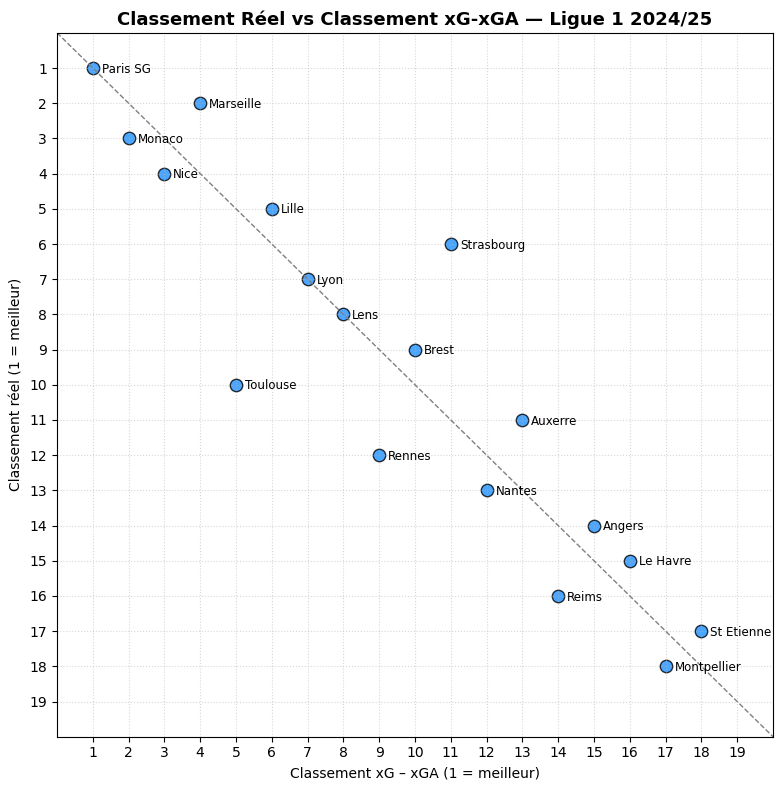

In [21]:
#Plot Classement vs Classement_xG
plt.figure(figsize=(8, 8))
plt.scatter(
    df_analysis["Classement_Balance_xG"],
    df_analysis["Classement"],
    s=80,
    color="dodgerblue",
    edgecolor="black",
    alpha=0.8,
)

# Noms des équipes
for _, row in df_analysis.iterrows():
    plt.text(
        row["Classement_Balance_xG"] + 0.25,
        row["Classement"] + 0.13,
        row["Equipe"],
        fontsize=8.5,
    )

# Diagonale (équipes en ligne avec leurs attendus)
plt.plot([0, 20], [0, 20], color="gray", linestyle="--", linewidth=1)

plt.title("Classement Réel vs Classement xG-xGA — Ligue 1 2024/25", fontsize=13, weight="bold")
plt.xlabel("Classement xG – xGA (1 = meilleur)")
plt.ylabel("Classement réel (1 = meilleur)")

plt.xlim(0, 20)
plt.ylim(20, 0)  # 1 en haut
plt.xticks(range(1, 20))
plt.yticks(range(1, 20))

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


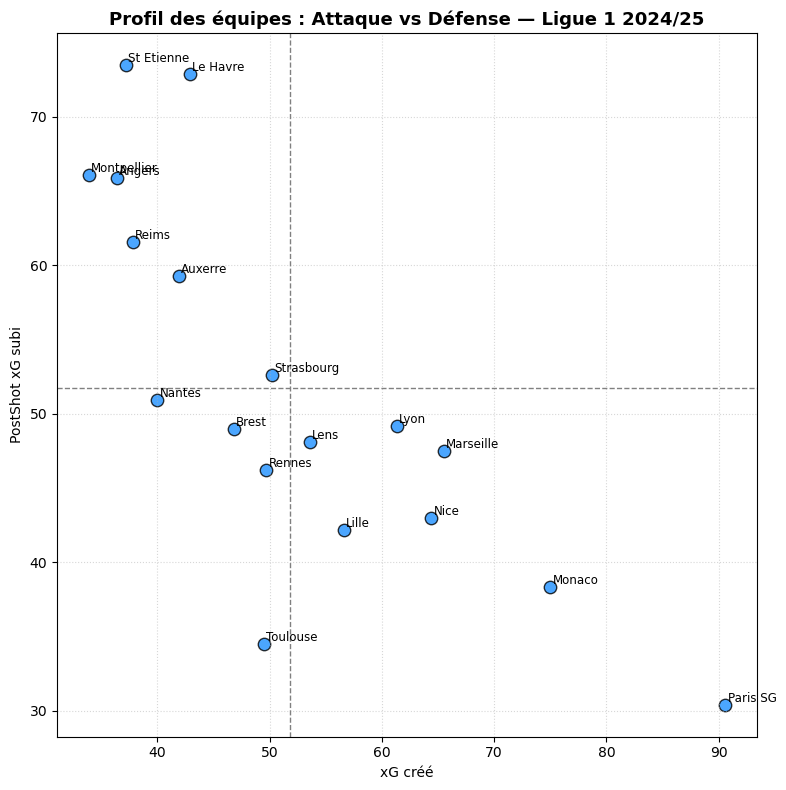

In [23]:
plt.figure(figsize=(8, 8))

plt.scatter(
    df_analysis["xG_Pour"],
    df_analysis["PostShot_xG_Subi"],
    s=80,
    color="dodgerblue",
    edgecolor="black",
    alpha=0.8,
)

# Labels équipes
for _, row in df_analysis.iterrows():
    plt.text(
        row["xG_Pour"] + 0.2,
        row["PostShot_xG_Subi"] + 0.2,
        row["Equipe"],
        fontsize=8.5,
    )

# Lignes moyennes
plt.axvline(df_analysis["xG_Pour"].mean(), linestyle="--", linewidth=1, color="gray")
plt.axhline(df_analysis["PostShot_xG_Subi"].mean(), linestyle="--", linewidth=1, color="gray")

plt.title("Profil des équipes : Attaque vs Défense — Ligue 1 2024/25", fontsize=13, weight="bold")
plt.xlabel("xG créé")
plt.ylabel("PostShot xG subi")

plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

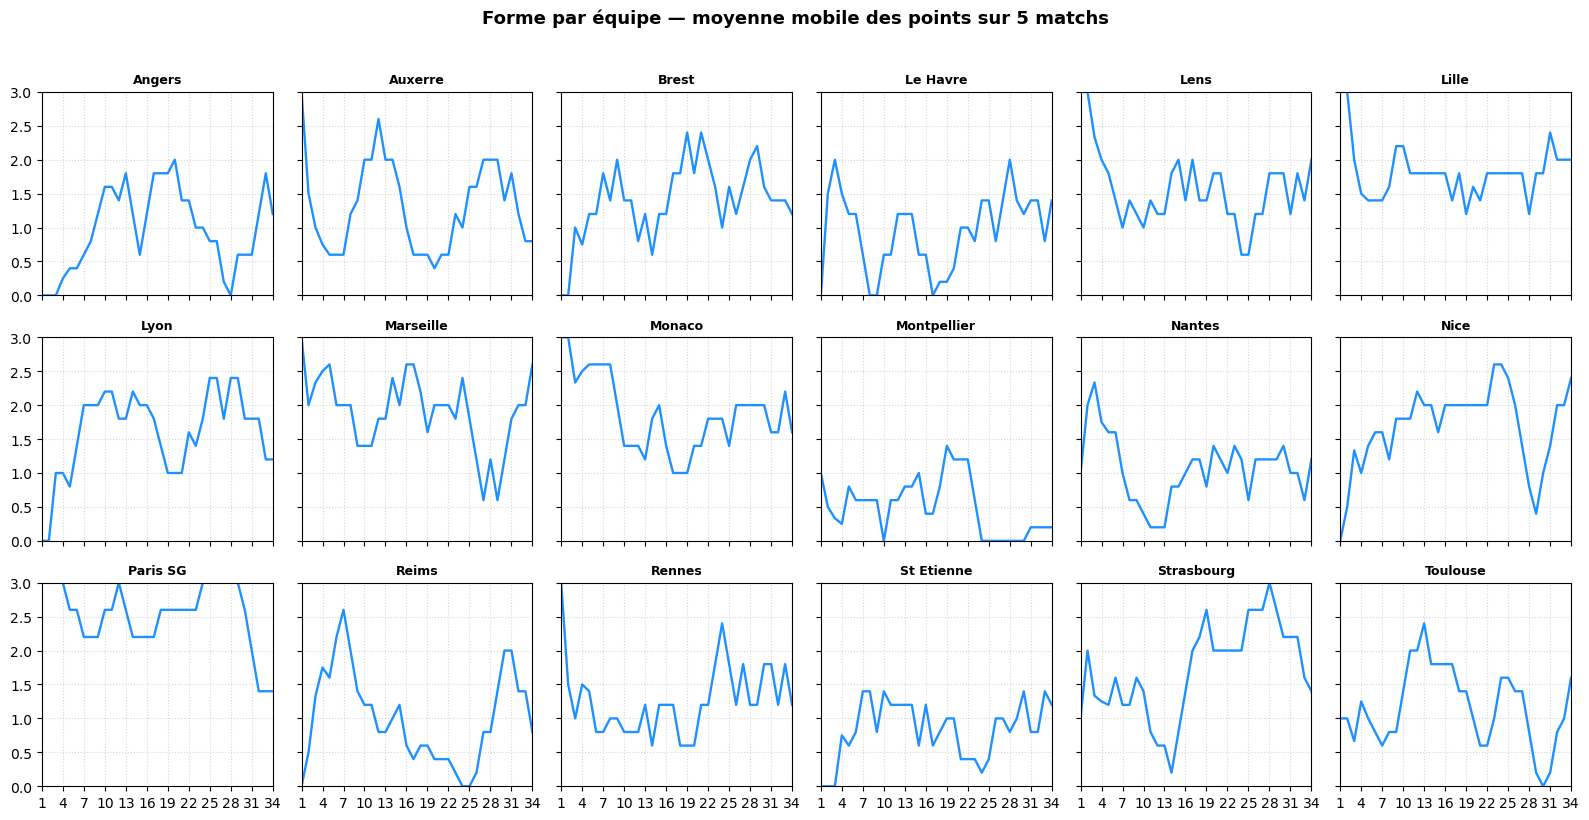

In [25]:
df_form, col_rolling = build_form_table(df_matchs, window=5)
plot_form_small_multiples(df_form, col_rolling, cols=6)

In [27]:
# Dossier d'export
EXPORT_DIR = Path("data/processed")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Exports principaux
df_players.to_csv(EXPORT_DIR / "ligue1_players_clean.csv", index=False)
df_team_matches.to_csv(EXPORT_DIR / "ligue1_team_matches.csv", index=False)
df_team_summary.to_csv(EXPORT_DIR / "ligue1_team_summary.csv", index=False)
df_analysis.to_csv(EXPORT_DIR / "ligue1_team_analysis.csv", index=False)
df_form.to_csv(EXPORT_DIR / "ligue1_team_form.csv", index=False)

print("Exports réalisés avec succès dans :", EXPORT_DIR)
print("- ligue1_players_clean.csv")
print("- ligue1_team_matches.csv")
print("- ligue1_team_summary.csv")
print("- ligue1_team_analysis.csv")
print("- ligue1_team_form.csv")

Exports réalisés avec succès dans : data\processed
- ligue1_players_clean.csv
- ligue1_team_matches.csv
- ligue1_team_summary.csv
- ligue1_team_analysis.csv
- ligue1_team_form.csv
